<a href="https://colab.research.google.com/github/Tuanyatuanya/MSSP607/blob/main/Participation_Week_08_Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.holtwinters import ExponentialSmoothing

Mounted at /content/drive


In [ ]:
!git clone https://github.com/tuanyatuanya/MSSP607.git

Cloning into 'MSSP607'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 149 (delta 74), reused 31 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (149/149), 1.25 MiB | 9.69 MiB/s, done.
Resolving deltas: 100% (74/74), done.


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MSSP607/Modules/Week_7 folder/InternetSales.csv', encoding='latin-1')
display(df.head())

/tmp/ipython-input-332926898.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/MSSP607/Modules/Week_7 folder/InternetSales.csv', encoding='latin-1')


,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,1/19/2011,1/31/2011,1/26/2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,8.2205,21.98,1.7584,0.5495,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,5/3/2013,5/15/2013,5/10/2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,10.8423,28.99,2.3192,0.7248,NaN,NaN,5/3/2013,5/15/2013,5/10/2013


In [ ]:
display(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 60 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        60398 non-null  int64  
 1   CustomerKey               60398 non-null  int64  
 2   GeographyKey              60398 non-null  int64  
 3   City                      60398 non-null  object 
 4   CountryRegionCode         60398 non-null  object 
 5   EnglishCountryRegionName  60398 non-null  object 
 6   CustomerAlternateKey      60398 non-null  object 
 7   Title                     307 non-null    object 
 8   FirstName                 60398 non-null  object 
 9   MiddleName                34903 non-null  object 
 10  LastName                  60398 non-null  object 
 11  NameStyle                 60398 non-null  bool   
 12  BirthDate                 60398 non-null  object 
 13  MaritalStatus             60398 non-null  object 
 14  Suffix

None

In [ ]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [ ]:
df['year'] = df['OrderDate'].dt.year
df['month'] = df['OrderDate'].dt.month
df['day_of_week'] = df['OrderDate'].dt.dayofweek
display(df[['OrderDate', 'year', 'month', 'day_of_week']].head())

,OrderDate,year,month,day_of_week
0,2011-01-19,2011,1,2
1,2013-01-18,2013,1,4
2,2013-01-18,2013,1,4
3,2013-05-03,2013,5,4
4,2013-05-03,2013,5,4


In [ ]:
sales_ts = df.groupby('OrderDate')['SalesAmount'].sum().reset_index()
sales_ts = sales_ts.sort_values(by='OrderDate')

In [ ]:
sales_ts['OrderDate'] = pd.to_datetime(sales_ts['OrderDate'])
sales_ts = sales_ts.set_index('OrderDate')

In [ ]:
monthly_sales = sales_ts['SalesAmount'].resample('MS').sum()

In [ ]:
model = ExponentialSmoothing(
    monthly_sales,
    trend='add',
    seasonal='mul',
    seasonal_periods=12
).fit()

In [ ]:
forecast_periods = 60
forecast = model.forecast(forecast_periods)
forecast_index = pd.date_range(
    start=monthly_sales.index[-1] + pd.offsets.MonthBegin(),
    periods=forecast_periods,
    freq='MS'
)
forecast_df = pd.DataFrame({'Date': forecast_index, 'Forecast_Sales': forecast})


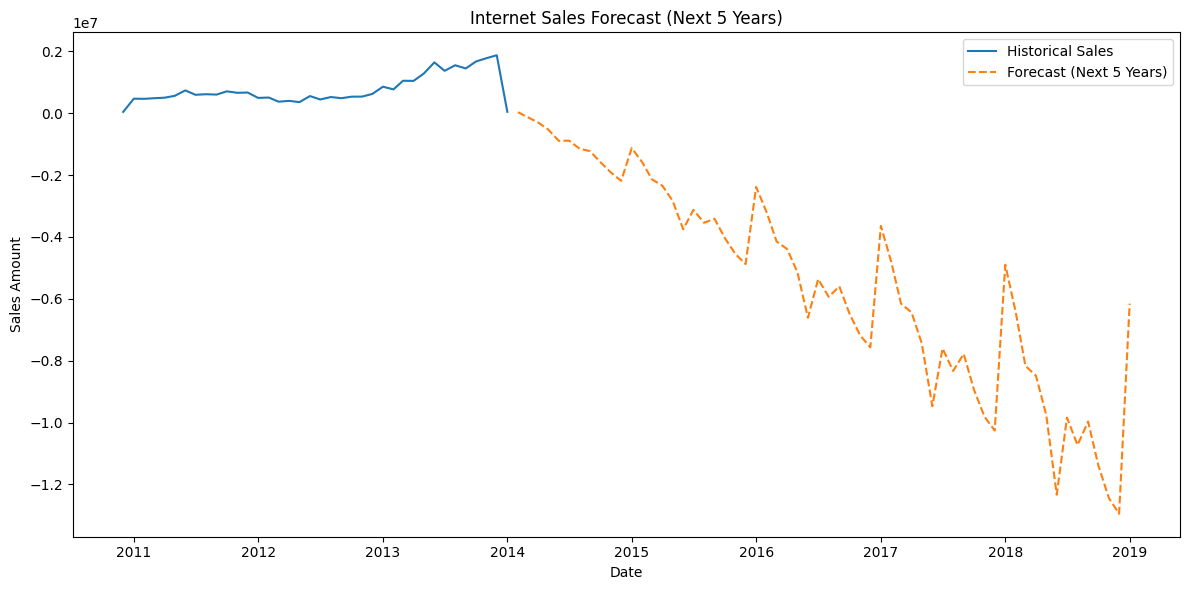

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, label='Historical Sales')
plt.plot(forecast_df['Date'], forecast_df['Forecast_Sales'], label='Forecast (Next 5 Years)', linestyle='--')
plt.title('Internet Sales Forecast (Next 5 Years)')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
display(forecast_df.head())

,Date,Forecast_Sales
2014-02-01,2014-02-01,34729.985092
2014-03-01,2014-03-01,-124456.918808
2014-04-01,2014-04-01,-297403.226647
2014-05-01,2014-05-01,-526670.163631
2014-06-01,2014-06-01,-892170.607346


In [ ]:
product_sales = (
    df.groupby('EnglishProductName')['SalesAmount']
      .agg(['count', 'sum', 'mean', 'median', 'std'])
      .sort_values(by='sum', ascending=False)
      .reset_index()
)

top_products = product_sales.head(10)
display(top_products)

best_product = top_products.iloc[0]
print(f"The product generating the most sales is '{best_product['EnglishProductName']}' "
      f"with total sales of ${best_product['sum']:,.2f}.")

,EnglishProductName,count,sum,mean,median,std
0,"Mountain-200 Black, 46",620,1.373470e+06,2215.273465,2294.99,115.188180
1,"Mountain-200 Black, 42",614,1.363142e+06,2220.101129,2294.99,113.256820
2,"Mountain-200 Silver, 38",596,1.339463e+06,2247.420789,2319.99,113.109387
3,"Mountain-200 Silver, 46",580,1.301100e+06,2243.276032,2319.99,114.919793
4,"Mountain-200 Black, 38",582,1.294866e+06,2224.855913,2294.99,111.120758
5,"Mountain-200 Silver, 42",560,1.257435e+06,2245.418880,2319.99,114.011108
6,"Road-150 Red, 48",337,1.205877e+06,3578.270000,3578.27,0.000000
7,"Road-150 Red, 62",336,1.202299e+06,3578.270000,3578.27,0.000000
8,"Road-150 Red, 52",302,1.080638e+06,3578.270000,3578.27,0.000000
9,"Road-150 Red, 56",295,1.055590e+06,3578.270000,3578.27,0.000000


The product generating the most sales is 'Mountain-200 Black, 46' with total sales of $1,373,469.55.
